# 01 — Math Essentials for Deep Learning

**INSEA Innovation Edge · Deep Learning Workshop**

---

Welcome! This notebook runs alongside the slides during **Blocks 2 and 3** of the session.
It covers the math foundations of deep learning — not through abstract formulas, but through
**interactive code you can run, tweak, and explore**.

**How to use this notebook:**
- Run cells top to bottom with **Shift + Enter**
- In interactive cells, move the sliders and watch what changes
- Read every markdown cell — they carry the full explanation

> **Tip:** You don't need to memorize formulas — you need to build intuition.
> The code does the math, **you do the thinking.**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, Dropdown

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    try:
        plt.style.use('seaborn-whitegrid')
    except OSError:
        pass

NAVY   = '#0D1B4B'
ACCENT = '#1E6FCC'
LIGHT  = '#5BA3E8'

print('Setup complete. Ready to build some intuition!')

Setup complete. Ready to build some intuition!


## Section 1 — What is a Weight?

Imagine a neuron in a neural network. It receives several inputs — maybe pixel values from an image,
sensor readings, or word scores.

Each input has a **weight**: a number that says *"how much should I trust this input?"*

- A **high weight** → this matters a lot
- A **weight near zero** → almost ignore this
- A **negative weight** → this works against the decision

The core operation every neuron performs is called the **dot product** — a weighted sum:

    output = (input_1 * weight_1) + (input_2 * weight_2) + ...

**Concrete example:** A student's final grade:

    final = 0.4 * exam + 0.3 * homework + 0.3 * project

Those three numbers `0.4, 0.3, 0.3` are the weights.
A neural network **learns the best weights** for its task — automatically.

In [2]:
# --- Change these values to experiment ---
exam_score     = 85
homework_score = 90
project_score  = 78

inputs  = [exam_score, homework_score, project_score]
weights = [0.4, 0.3, 0.3]
labels  = ['Exam', 'Homework', 'Project']

# Step by step
print('Step-by-step calculation:')
print('-' * 38)
total = 0
for label, val, w in zip(labels, inputs, weights):
    contribution = val * w
    print(f'  {label:10s}: {val} x {w} = {contribution:.2f}')
    total += contribution

print('-' * 38)
print(f'  Manual sum  = {total:.2f}')
print(f'  np.dot()    = {np.dot(inputs, weights):.2f}')

Step-by-step calculation:
--------------------------------------
  Exam      : 85 x 0.4 = 34.00
  Homework  : 90 x 0.3 = 27.00
  Project   : 78 x 0.3 = 23.40
--------------------------------------
  Manual sum  = 84.40
  np.dot()    = 84.40


### What just happened?

The dot product is a **weighted sum** — each input is multiplied by its weight, then all results are added.
Every neuron in a neural network computes exactly this operation.
The weights are the numbers the network **learns** during training.

In [ ]:
def plot_weighted_sum(x1, x2, x3, w1, w2, w3):
    products = [x1*w1, x2*w2, x3*w3]
    dot      = sum(products)

    labels = ['Input 1 x W1', 'Input 2 x W2', 'Input 3 x W3', 'Dot Product (sum)']
    values = products + [dot]
    colors = [LIGHT, LIGHT, LIGHT, ACCENT]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(labels, values, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlim(-1.5, 1.5)
    ax.set_title('Weighted Sum — move the sliders', color=NAVY, fontsize=13, fontweight='bold')
    ax.set_xlabel('Value')

    for bar, val in zip(bars, values):
        xpos = val + 0.03 if val >= 0 else val - 0.03
        ha   = 'left'      if val >= 0 else 'right'
        ax.text(xpos, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', ha=ha, fontsize=10)

    plt.tight_layout()
    plt.show()

interact(
    plot_weighted_sum,
    x1=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05, description='Input 1'),
    x2=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05, description='Input 2'),
    x3=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.05, description='Input 3'),
    w1=FloatSlider(value=0.4, min=-1.0, max=1.0, step=0.05, description='Weight 1'),
    w2=FloatSlider(value=0.3, min=-1.0, max=1.0, step=0.05, description='Weight 2'),
    w3=FloatSlider(value=0.3, min=-1.0, max=1.0, step=0.05, description='Weight 3'),
);

interactive(children=(FloatSlider(value=0.5, description='Input 1', max=1.0, step=0.05), FloatSlider(value=0.5…

---

The dot product gives us a **number** — a neuron's output.

But what if we want to know how **wrong** that number is?
That's exactly what a **loss function** measures.

## Section 2 — What is Loss?

Imagine you predicted there was an **80% chance of rain** today. It rained. Good call!

Now imagine you predicted **10%** and it rained. Bad call.

A **loss function** turns that "badness" into a single number:
- A perfect model has **loss = 0**
- A terrible model has **high loss**

The network's entire job during training is to **minimize this number**.

---

The simplest loss function is **Mean Squared Error (MSE)**:

> For each prediction, compute the error (prediction − truth), square it, then average all of them.

In plain English: *"On average, how far off were my predictions — penalizing big mistakes more than small ones?"*

    MSE = average of (prediction - truth)^2

In [4]:
# Our ground truth and predictions
true_values = np.array([1.0, 0.0, 1.0, 1.0, 0.0])
predictions = np.array([0.8, 0.2, 0.9, 0.4, 0.1])

# Step by step
errors  = predictions - true_values    # how wrong?
squared = errors ** 2                  # penalize big mistakes more
mse     = np.mean(squared)             # average it

# Formatted table
print(f"{'True':>6} | {'Predicted':>10} | {'Error':>7} | {'Squared':>8}")
print('-' * 40)

for t, p, e, s in zip(true_values, predictions, errors, squared):
    print(f'{t:>6.1f} | {p:>10.2f} | {e:>7.3f} | {s:>8.4f}')
print('-' * 40)
print(f'{"MSE":>6}   {"":>10}   {"":>7}   {mse:>8.4f}')
print()
print(f'Shortcut: np.mean((predictions - true_values)**2) = {np.mean((predictions - true_values)**2):.4f}')

  True |  Predicted |   Error |  Squared
----------------------------------------
   1.0 |       0.80 |  -0.200 |   0.0400
   0.0 |       0.20 |   0.200 |   0.0400
   1.0 |       0.90 |  -0.100 |   0.0100
   1.0 |       0.40 |  -0.600 |   0.3600
   0.0 |       0.10 |   0.100 |   0.0100
----------------------------------------
   MSE                            0.0920

Shortcut: np.mean((predictions - true_values)**2) = 0.0920


In [5]:
# Tiny dataset: true relationship is y = 2*x
x_data = np.array([1.0, 2.0, 3.0])
y_data = np.array([2.0, 4.0, 6.0])

# Pre-compute loss for every weight in the range
w_range    = np.linspace(-3, 3, 300)
loss_curve = np.array([np.mean((w * x_data - y_data)**2) for w in w_range])

def plot_loss_surface(weight):
    current_loss = np.mean((weight * x_data - y_data)**2)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(w_range, loss_curve, color=ACCENT, linewidth=2.5, label='Loss curve')
    ax.scatter([weight], [current_loss], color='red', s=130, zorder=5)
    ax.annotate(f'  loss = {current_loss:.3f}', xy=(weight, current_loss),
                fontsize=11, color='red', fontweight='bold')
    ax.set_xlabel('Weight value', fontsize=11)
    ax.set_ylabel('Loss (MSE)', fontsize=11)
    ax.set_title('Loss Surface — drag the slider to find the minimum', color=NAVY, fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

interact(
    plot_loss_surface,
    weight=FloatSlider(value=0.0, min=-3.0, max=3.0, step=0.1, description='Weight')
);

interactive(children=(FloatSlider(value=0.0, description='Weight', max=3.0, min=-3.0), Output()), _dom_classes…

### What just happened?

The parabola IS the **loss surface** — it shows how wrong we are for every possible weight value.
The **bottom of the curve** is where our model is most accurate (loss is lowest).
**Gradient descent** is an algorithm that automatically finds that bottom — that's what the next section covers.

## Section 3 — Gradient Descent (Walking Downhill)

Picture this: you're standing on a hilly landscape, **blindfolded**. You want to reach the lowest point.

Your strategy:
1. Feel the slope under your feet
2. Take one step in the **downhill direction**
3. Repeat

That's gradient descent. At each step, it computes **which direction reduces the loss** and moves the weight that way.

The size of each step is controlled by the **learning rate** (`lr`).

**The update rule:**

    new_weight = old_weight - lr * gradient

- `gradient` = the slope of the loss curve at your current position
- `lr` = how big a step to take (too small = slow, too large = overshoot and diverge)

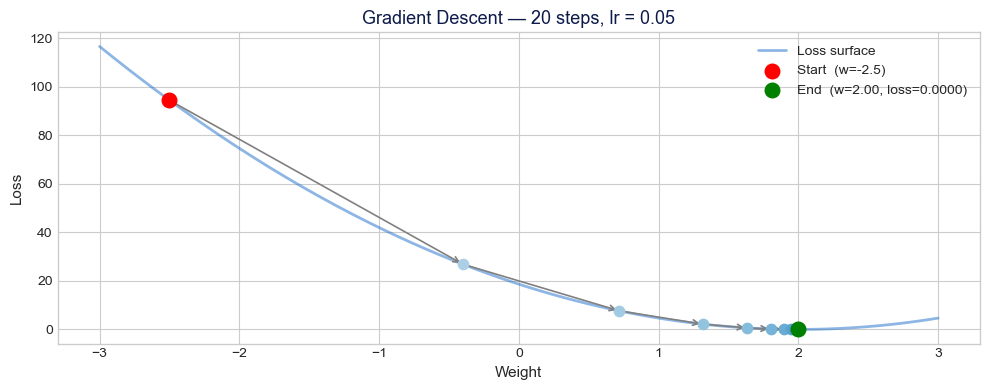

In [6]:
x_data = np.array([1.0, 2.0, 3.0])
y_data = np.array([2.0, 4.0, 6.0])

def mse(w):
    return np.mean((w * x_data - y_data) ** 2)

def gradient(w):
    return np.mean(2 * (w * x_data - y_data) * x_data)

# Run gradient descent for 20 steps
lr      = 0.05
w       = -2.5
history = [(w, mse(w))]

for _ in range(20):
    w = w - lr * gradient(w)
    history.append((w, mse(w)))

ws, losses = zip(*history)

# --- Plot ---
w_range    = np.linspace(-3, 3, 200)
loss_curve = [mse(wi) for wi in w_range]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(w_range, loss_curve, color=ACCENT, linewidth=2, alpha=0.5, label='Loss surface')

# Draw arrows between steps
for i in range(len(ws) - 1):
    ax.annotate('', xy=(ws[i+1], losses[i+1]), xytext=(ws[i], losses[i]),
                arrowprops=dict(arrowstyle='->', color='gray', lw=1.2))

# Dots shaded from dark (start) to bright (end)
for i in range(len(ws)):
    shade = 0.3 + 0.7 * i / max(len(ws) - 1, 1)
    ax.scatter([ws[i]], [losses[i]], color=plt.cm.Blues(shade), s=55, zorder=5)

ax.scatter([ws[0]],  [losses[0]],  color='red',   s=110, zorder=6, label=f'Start  (w={ws[0]:.1f})')
ax.scatter([ws[-1]], [losses[-1]], color='green', s=110, zorder=6,
           label=f'End  (w={ws[-1]:.2f}, loss={losses[-1]:.4f})')

ax.set_xlabel('Weight', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('Gradient Descent — 20 steps, lr = 0.05', color=NAVY, fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
x_data = np.array([1.0, 2.0, 3.0])
y_data = np.array([2.0, 4.0, 6.0])

def mse(w):
    return np.mean((w * x_data - y_data) ** 2)

def grad(w):
    return np.mean(2 * (w * x_data - y_data) * x_data)

def run_gd(lr, steps=30):
    w      = -2.5
    losses = [mse(w)]
    for _ in range(steps):
        w = w - lr * grad(w)
        losses.append(min(mse(w), 1000))   # cap to avoid Inf display
    return losses

def plot_lr(learning_rate):
    losses = run_gd(learning_rate)
    final  = losses[-1]

    if final > 100:
        color = 'red'
        title = f'lr = {learning_rate}  —  Learning rate too large — diverging!'
    elif final < 0.1:
        color = 'green'
        title = f'lr = {learning_rate}  —  Good learning rate — converged!'
    else:
        color = 'orange'
        title = f'lr = {learning_rate}  —  Learning rate too small — very slow'

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(losses, color=color, linewidth=2.5)
    ax.set_xlabel('Training step', fontsize=11)
    ax.set_ylabel('Loss', fontsize=11)
    ax.set_ylim(0, min(max(losses) * 1.1, 500))
    ax.set_title(title, color=NAVY, fontsize=13)
    plt.tight_layout()
    plt.show()

interact(
    plot_lr,
    learning_rate=Dropdown(
        options=[0.001, 0.01, 0.1, 0.5, 1.0, 2.0],
        value=0.1,
        description='Learning Rate'
    )
);

interactive(children=(Dropdown(description='Learning Rate', index=2, options=(0.001, 0.01, 0.1, 0.5, 1.0, 2.0)…

### What just happened?

- **Small learning rate** (`0.001`): converges safely but very slowly — takes many more steps than needed
- **Good learning rate** (`0.1`): finds the minimum in ~10–20 steps — the sweet spot
- **Large learning rate** (`2.0`): loss **explodes** — steps overshoot the minimum and the model never converges

In Workshop 1, we'll break a real network on purpose by setting `lr = 10` to see this effect live.

## Section 4 — Activation Functions (Adding Non-linearity)

Here's a problem: a neuron computes a dot product — a **linear** operation.

Stack 100 linear operations on top of each other... and you still get a linear operation.
A 100-layer network with no activation functions is mathematically equivalent to **a single layer**. Useless.

**Activation functions** solve this by adding non-linearity after each neuron.
They decide: *"How much of this signal should I pass forward?"*

---

The four main ones:

| Function | Behavior | Best used for |
|---|---|---|
| **ReLU** | Negative → 0, positive → unchanged | Hidden layers (default choice) |
| **Sigmoid** | Squishes output to 0–1 | Binary classification output |
| **Tanh** | Like sigmoid but centered at 0 | Recurrent networks (RNNs) |
| **Softmax** | Converts scores to probabilities that sum to 1 | Multi-class output layer |

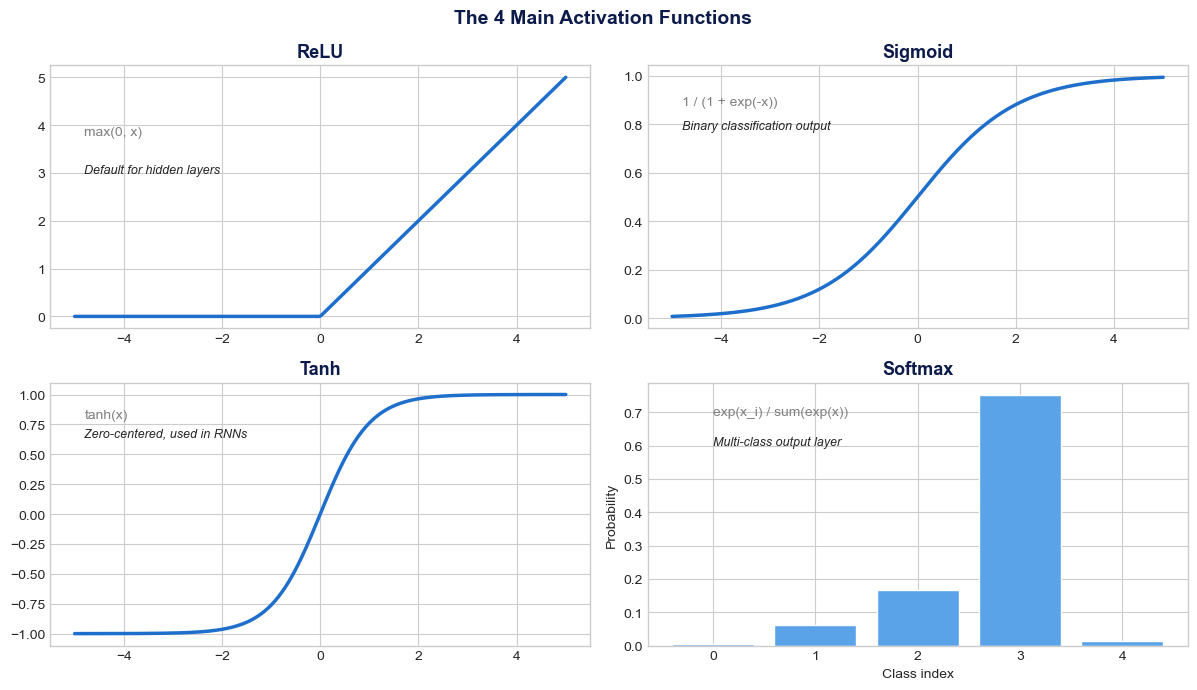

In [8]:
x = np.linspace(-5, 5, 300)

relu    = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh_f  = np.tanh(x)

# Softmax applied to a fixed 5-element vector
z_vec   = np.array([-2.0, 0.5, 1.5, 3.0, -1.0])
softmax = np.exp(z_vec) / np.sum(np.exp(z_vec))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.suptitle('The 4 Main Activation Functions', fontsize=14, color=NAVY, fontweight='bold')

# ReLU
axes[0, 0].plot(x, relu, color=ACCENT, linewidth=2.5)
axes[0, 0].set_title('ReLU', fontsize=13, color=NAVY, fontweight='bold')
axes[0, 0].text(-4.8, 3.8, 'max(0, x)', fontsize=10, color='gray')
axes[0, 0].text(-4.8, 3.0, 'Default for hidden layers', fontsize=9, style='italic')

# Sigmoid
axes[0, 1].plot(x, sigmoid, color=ACCENT, linewidth=2.5)
axes[0, 1].set_title('Sigmoid', fontsize=13, color=NAVY, fontweight='bold')
axes[0, 1].text(-4.8, 0.88, '1 / (1 + exp(-x))', fontsize=10, color='gray')
axes[0, 1].text(-4.8, 0.78, 'Binary classification output', fontsize=9, style='italic')

# Tanh
axes[1, 0].plot(x, tanh_f, color=ACCENT, linewidth=2.5)
axes[1, 0].set_title('Tanh', fontsize=13, color=NAVY, fontweight='bold')
axes[1, 0].text(-4.8, 0.80, 'tanh(x)', fontsize=10, color='gray')
axes[1, 0].text(-4.8, 0.64, 'Zero-centered, used in RNNs', fontsize=9, style='italic')

# Softmax as bar chart
axes[1, 1].bar(range(len(softmax)), softmax, color=LIGHT, edgecolor='white')
axes[1, 1].set_title('Softmax', fontsize=13, color=NAVY, fontweight='bold')
axes[1, 1].set_xlabel('Class index')
axes[1, 1].set_ylabel('Probability')
axes[1, 1].text(0, max(softmax) * 0.92, 'exp(x_i) / sum(exp(x))', fontsize=10, color='gray')
axes[1, 1].text(0, max(softmax) * 0.80, 'Multi-class output layer', fontsize=9, style='italic')

plt.tight_layout()
plt.show()

In [ ]:
def apply_act(name, x_val):
    if name == 'ReLU':
        return float(max(0.0, x_val))
    elif name == 'Sigmoid':
        return float(1 / (1 + np.exp(-x_val)))
    elif name == 'Tanh':
        return float(np.tanh(x_val))
    return 0.0

x_range = np.linspace(-5, 5, 300)

def plot_activation(activation, input_value):
    y_range = [apply_act(activation, xi) for xi in x_range]
    output  = apply_act(activation, input_value)

    bar_color = ACCENT if output > 0.1 else ('gray' if output > -0.1 else LIGHT)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('What does this neuron output?', fontsize=13, color=NAVY, fontweight='bold')

    # Left: function curve with current input/output marked
    ax1.plot(x_range, y_range, color=ACCENT, linewidth=2.5)
    ax1.axvline(input_value, color='red',   linestyle='--', linewidth=1.5, label='input')
    ax1.axhline(output,      color='green', linestyle='--', linewidth=1.5, label='output')
    ax1.scatter([input_value], [output], s=100, color='red', zorder=5)
    ax1.set_title(f'{activation} function', fontsize=12)
    ax1.legend()

    # Right: output value as bar
    ax2.bar(['Output'], [abs(output)], color=bar_color, width=0.4)
    ax2.set_ylim(0, 1.15)
    ax2.set_title(f'Neuron output: {output:.4f}', fontsize=12)
    ax2.text(0, abs(output) + 0.06, f'{output:.4f}', ha='center', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.show()

interact(
    plot_activation,
    activation=Dropdown(options=['ReLU', 'Sigmoid', 'Tanh'], value='ReLU', description='Function'),
    input_value=FloatSlider(value=1.0, min=-5.0, max=5.0, step=0.1, description='Input')
);

interactive(children=(Dropdown(description='Function', options=('ReLU', 'Sigmoid', 'Tanh'), value='ReLU'), Flo…

### Rule of Thumb for Beginners

**Use ReLU in all hidden layers.**
**Use Softmax on the output layer when classifying into multiple classes.**

That covers 90% of everything you will build today.

## Section 5 — Backpropagation (How the Network Learns)

We've seen:
- **Forward pass** → the network makes a prediction
- **Loss** → we measure how wrong it is

But how does the network know **which weights caused the error** — and how much to change each one?

That's **backpropagation**.

It works **backward from the loss**. For each weight, it asks:
> *"If I nudge this weight by a tiny amount, how much does the loss change?"*

That ratio is the **gradient**. Each weight gets its own gradient, and we use it to update that weight via gradient descent.

The **chain rule** from calculus makes this efficient: gradients flow backward through the network layer by layer.
You don't need to understand the chain rule to use deep learning — PyTorch handles it with a single call to `loss.backward()`.

In [10]:
# A tiny 2-layer network by hand:
#   2 inputs  ->  1 hidden neuron (ReLU)  ->  1 output (linear)

inputs   = np.array([1.0, 0.5])
true_out = 1.0
lr       = 0.1

# Initial weights (fixed for reproducibility)
w1 = np.array([0.6, -0.4])   # weights into hidden neuron
b1 = 0.1                      # hidden bias
w2 = 0.8                      # weight into output
b2 = 0.0                      # output bias

# ── FORWARD PASS ─────────────────────────────────────
print('=' * 45)
print('FORWARD PASS')
print('=' * 45)

z1   = np.dot(w1, inputs) + b1        # hidden pre-activation
a1   = max(0.0, z1)                    # ReLU activation
z2   = w2 * a1 + b2                   # output pre-activation
pred = z2                              # linear output
loss = (pred - true_out) ** 2         # squared error loss

print(f'Hidden pre-activation  z1  = {z1:.4f}')
print(f'After ReLU             a1  = {a1:.4f}')
print(f'Output pre-activation  z2  = {z2:.4f}')
print(f'Prediction             y^  = {pred:.4f}')
print(f'Loss (squared error)       = {loss:.4f}')

# ── BACKWARD PASS ────────────────────────────────────
print()
print('=' * 45)
print('BACKWARD PASS')
print('=' * 45)

d_loss_pred = 2 * (pred - true_out)           # d(loss)/d(pred)
d_loss_w2   = d_loss_pred * a1                # d(loss)/d(w2)
relu_grad   = 1.0 if z1 > 0 else 0.0         # ReLU derivative
d_loss_a1   = d_loss_pred * w2               # pass gradient back through output weight
d_loss_z1   = d_loss_a1 * relu_grad           # pass gradient back through ReLU
d_loss_w1   = d_loss_z1 * inputs             # d(loss)/d(w1)

print(f'd(loss)/d(pred) = {d_loss_pred:.4f}')
print(f'd(loss)/d(w2)   = {d_loss_w2:.4f}')
print(f'd(loss)/d(z1)   = {d_loss_z1:.4f}')
print(f'd(loss)/d(w1)   = {d_loss_w1}')

# ── WEIGHT UPDATE ────────────────────────────────────
print()
print('=' * 45)
print('WEIGHT UPDATE  (new = old - lr * gradient)')
print('=' * 45)

w2_new = w2 - lr * d_loss_w2
w1_new = w1 - lr * d_loss_w1

print(f'w2:  {w2:.4f}  ->  {w2_new:.4f}')
print(f'w1:  {w1}  ->  {w1_new}')

# Verify loss went down
z1_new   = np.dot(w1_new, inputs) + b1
a1_new   = max(0.0, z1_new)
pred_new = w2_new * a1_new + b2
loss_new = (pred_new - true_out) ** 2

print()
print(f'Loss before: {loss:.6f}')
print(f'Loss after:  {loss_new:.6f}  <- should be lower!')

FORWARD PASS
Hidden pre-activation  z1  = 0.5000
After ReLU             a1  = 0.5000
Output pre-activation  z2  = 0.4000
Prediction             y^  = 0.4000
Loss (squared error)       = 0.3600

BACKWARD PASS
d(loss)/d(pred) = -1.2000
d(loss)/d(w2)   = -0.6000
d(loss)/d(z1)   = -0.9600
d(loss)/d(w1)   = [-0.96 -0.48]

WEIGHT UPDATE  (new = old - lr * gradient)
w2:  0.8000  ->  0.8600
w1:  [ 0.6 -0.4]  ->  [ 0.696 -0.352]

Loss before: 0.360000
Loss after:  0.217902  <- should be lower!


### What just happened?

1. **Forward pass** — the network made a prediction using the current weights
2. **Backward pass** — we computed how much each weight contributed to the error (its gradient)
3. **Update step** — every weight was nudged slightly to reduce the loss

This is exactly what PyTorch does automatically:
- `loss.backward()` runs the backward pass and fills in all gradients
- `optimizer.step()` applies the weight update for every parameter

In Workshop 1, those two lines replace everything you just computed by hand.

---

## What You Just Learned

- **Weights & dot products** — neurons compute weighted sums; the weights are what the network learns
- **Loss functions** — MSE quantifies how wrong the model is; training minimizes this number
- **Gradient descent** — walks downhill on the loss surface; learning rate controls the step size
- **Activation functions** — ReLU, Sigmoid, Tanh, Softmax add non-linearity that makes deep networks powerful
- **Backpropagation** — gradients flow backward through the network so every weight knows how to improve

---

## What's Next

Open **`02_mnist_workshop.ipynb`** — you'll use everything above to train a real neural network on handwritten digits.

Every concept maps directly:
- `np.dot()` → `nn.Linear()`
- manual gradient → `loss.backward()`
- weight update loop → `optimizer.step()`

---

*INSEA Innovation Edge · Deep Learning Workshop*